**Car Price Prediction using Machine Learning**

It is a simple data science project that uses machine learning to predict the resale price of a car based on features like year, present price, kilometers driven, fuel type, transmission, and ownership type. It includes data analysis, visualization, model training, and an interactive dashboards to make real-time price predictions.

**Step 1: Import Libraries**

In [31]:
import pandas as pd #for file read and data manipulation
import numpy as np #for numeric calculations
import matplotlib.pyplot as plt #for data visualization
import seaborn as sns #for advance data visualization
from sklearn.model_selection import train_test_split #for spliting data into train and test sets
from sklearn.linear_model import LinearRegression #for numeric prediction
from sklearn.metrics import mean_absolute_error, r2_score #for evaluating model performance
import joblib

**Step 2: Load Dataset**

In [3]:
df = pd.read_csv('car data.csv')

**Step 3: Create a copy of dataset**

In [4]:
df_copy = df.copy()

**Step 4: Basic EDA**

In [7]:
print("Shape of Dataset: ")
df.shape

Shape of Dataset: 


(301, 9)

In [8]:
print("First 5 rows: ")
df.head()

First 5 rows: 


,Car_Name,Year,Selling_Price,Present_Price,Driven_kms,Fuel_Type,Selling_type,Transmission,Owner
0,ritz,2014,3.35,5.59,27000,Petrol,Dealer,Manual,0
1,sx4,2013,4.75,9.54,43000,Diesel,Dealer,Manual,0
2,ciaz,2017,7.25,9.85,6900,Petrol,Dealer,Manual,0
3,wagon r,2011,2.85,4.15,5200,Petrol,Dealer,Manual,0
4,swift,2014,4.60,6.87,42450,Diesel,Dealer,Manual,0


In [9]:
print("Last 5 rows: ")
df.tail()

Last 5 rows: 


,Car_Name,Year,Selling_Price,Present_Price,Driven_kms,Fuel_Type,Selling_type,Transmission,Owner
296,city,2016,9.50,11.6,33988,Diesel,Dealer,Manual,0
297,brio,2015,4.00,5.9,60000,Petrol,Dealer,Manual,0
298,city,2009,3.35,11.0,87934,Petrol,Dealer,Manual,0
299,city,2017,11.50,12.5,9000,Diesel,Dealer,Manual,0
300,brio,2016,5.30,5.9,5464,Petrol,Dealer,Manual,0


In [10]:
print("Column names of dataset: ")
df.columns

Column names of dataset: 


Index(['Car_Name', 'Year', 'Selling_Price', 'Present_Price', 'Driven_kms',
       'Fuel_Type', 'Selling_type', 'Transmission', 'Owner'],
      dtype='object')

In [11]:
print("Basic information about dataset: ")
df.info()

Basic information about dataset: 
<class 'pandas.core.frame.DataFrame'>
RangeIndex: 301 entries, 0 to 300
Data columns (total 9 columns):
 #   Column         Non-Null Count  Dtype  
---  ------         --------------  -----  
 0   Car_Name       301 non-null    object 
 1   Year           301 non-null    int64  
 2   Selling_Price  301 non-null    float64
 3   Present_Price  301 non-null    float64
 4   Driven_kms     301 non-null    int64  
 5   Fuel_Type      301 non-null    object 
 6   Selling_type   301 non-null    object 
 7   Transmission   301 non-null    object 
 8   Owner          301 non-null    int64  
dtypes: float64(2), int64(3), object(4)
memory usage: 21.3+ KB


In [12]:
print("Statistical Summary of dataset: ")
round(df.describe(), 2)

Statistical Summary of dataset: 


,Year,Selling_Price,Present_Price,Driven_kms,Owner
count,301.00,301.00,301.00,301.00,301.00
mean,2013.63,4.66,7.63,36947.21,0.04
std,2.89,5.08,8.64,38886.88,0.25
min,2003.00,0.10,0.32,500.00,0.00
25%,2012.00,0.90,1.20,15000.00,0.00
50%,2014.00,3.60,6.40,32000.00,0.00
75%,2016.00,6.00,9.90,48767.00,0.00
max,2018.00,35.00,92.60,500000.00,3.00


**Step 5: Checking missing values**

In [14]:
df.isnull().sum()

Car_Name         0
Year             0
Selling_Price    0
Present_Price    0
Driven_kms       0
Fuel_Type        0
Selling_type     0
Transmission     0
Owner            0
dtype: int64

No missing values = clean dataset

**Step 6: Data Visualization**

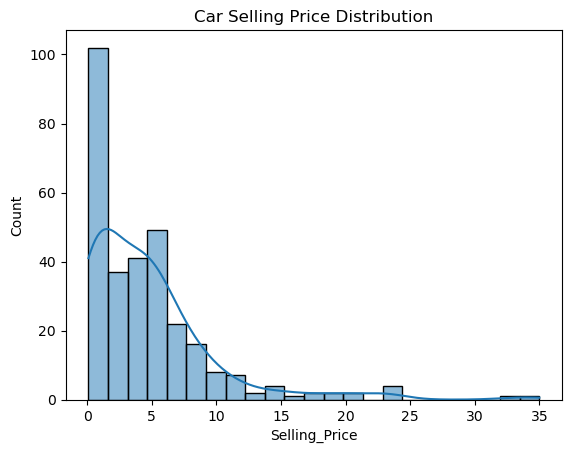

In [15]:
sns.histplot(df_copy['Selling_Price'], kde = True)
plt.title('Car Selling Price Distribution')
plt.savefig('Car_Selling_Price_Distribution.png')
plt.show()

## Insight:

1. Most cars are in low price range
2. Few luxury cars are very expensive

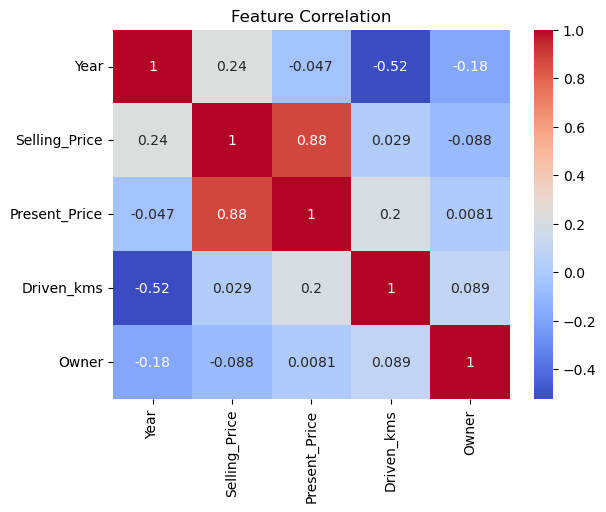

In [17]:
corr_metrix = df_copy.select_dtypes(include = np.number).corr()

sns.heatmap(corr_metrix, annot = True, cmap = 'coolwarm')
plt.title('Feature Correlation')
plt.savefig('Feature_Correlation.png')
plt.show()

## Insight:

1. Present price stringly affects selling price
2. year also impacts price
3. kms driven negatively affects price

**Step 7: Data Preprocessing**

As we know that ML model only understands number, so we convert text to numbers.

Here, we are using ordinal encoding [mapping]

In [19]:
df_copy['Fuel_Type'] = df_copy['Fuel_Type'].map({'Petrol' : 0, 'Diesel' : 1, 'CNG' : 2})
df_copy['Selling_type'] = df_copy['Selling_type'].map({'Dealer' : 0, 'Individual' : 1})
df_copy['Transmission'] = df_copy['Transmission'].map({'Manual' : 0, 'Automatic' : 1})

**Step 8: Feature Selection**

In [20]:
x = df_copy[['Year', 'Present_Price', 'Driven_kms', 'Fuel_Type', 'Selling_type', 'Transmission']]
y = df_copy['Selling_Price']

x -> Input features


y -> Output features

**Step 9: Train-Test Split**

In [22]:
x_train, x_test, y_train, y_test = train_test_split(x, y, test_size = 0.2, random_state = 42)

In [23]:
print(f'Total Samples: {len(df_copy)}')
print(f'Training Samples: {len(x_train)}')
print(f'Testing Samples: {len(x_test)}')

Total Samples: 301
Training Samples: 240
Testing Samples: 61


we will use 20% of data for test set and rest for training model and we have also use random state so that it keeps split same every run so overall it helps to test model on unseen data. 

**Step 10: Model Training**

In [24]:
model = LinearRegression()
model.fit(x_train, y_train)

,fit_intercept,True
,copy_X,True
,tol,1e-06
,n_jobs,None
,positive,False


Model learns relationship between features and price

In [25]:
print('Model Training Completed')

Model Training Completed


**Step 11: Prediction**

In [26]:
y_prediction = model.predict(x_test)

The model predicts selling price for test data

**Step 12: Evaluation**

In [28]:
print("R2 Score: ", r2_score(y_test, y_prediction))
print("MAE: ", mean_absolute_error(y_test, y_prediction))

R2 Score:  0.8522469354510648
MAE:  1.1917981071909733


R2 closer to 1 = good model


MAE = average error

In [33]:
accuracy = r2_score(y_test, y_prediction)

print(f'Model Accuracy: {accuracy * 100} %')

Model Accuracy: 85.22469354510648 %


**Step 13: Save Model**

In [32]:
joblib.dump(model, 'car_price_model.pkl')
print("Model Saved!")

Model Saved!


**Step 14: Important Insights**

1. Most cars are priced below ₹10 Lakhs.
2. Present price highly affects selling price.
3. Newer cars have higher resale value.
4. More driven kilometers reduce car price.
5. Diesel cars usually have better resale value.
6. Automatic cars are slightly more expensive.
7. Cars with fewer owners sell at better prices.
8. Dealer-listed cars are more common in the dataset.